In [1]:
#Logistic regression is used for classification (kinear regression used for prediction)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
df=pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
#1. Fill missing age values with the median age
df['Age']=df['Age'].fillna(df['Age'].median())
#2. Fill missing embarked values with the most common port
most_common_port=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(most_common_port)
#3. Convert 'Sex' to numeric: female->1,male->0
df['IsFemale']=df['Sex'].map({'female':1,'male':0})
#4. Select the features we want to use for classification
features=['Age','Fare','SibSp','Parch','IsFemale']
df[features].head()

,Age,Fare,SibSp,Parch,IsFemale
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [3]:
# 1. Binary Classification
x=df[features]
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print(f"Training Set: {x_train.shape[0]} rows")
print(f"Test Set: {x_test.shape[0]} rows")

Training Set: 712 rows
Test Set: 179 rows


Binary Classification Accuracy: 0.7821 (or 78.21%)


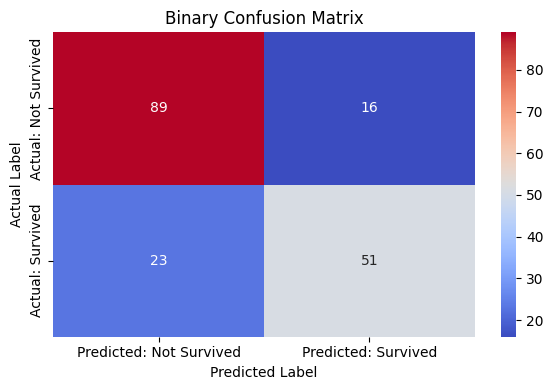

In [4]:
#Train Model
binary_model=LogisticRegression(max_iter=1000)
binary_model.fit(x_train,y_train)
#Predict and calculate accuracy
y_pred=binary_model.predict(x_test)
accuracy_bin=accuracy_score(y_test,y_pred)
print(f"Binary Classification Accuracy: {accuracy_bin:.4f} (or {accuracy_bin:.2%})")
#Confusion matrix
cm_bin=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_bin,annot=True,fmt='d',cmap='coolwarm',xticklabels=['Predicted: Not Survived' , 'Predicted: Survived'],yticklabels=['Actual: Not Survived','Actual: Survived'])
plt.title('Binary Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [5]:
#Multiclass Classification
df.columns.to_list()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked',
 'IsFemale']

In [8]:
features_multi=['Survived','Age','Fare','SibSp','Parch','IsFemale']
x=df[features_multi]
y=df['Pclass']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
multiclass_model=LogisticRegression(max_iter=1000)
multiclass_model.fit(x_train,y_train)
muticlass_pred=multiclass_model.predict(x_test)
multi_accuracy=accuracy_score(y_test,muticlass_pred)
print(f"Accuracy Score : {multi_accuracy:.2%}")

Accuracy Score : 82.68%


[[47  5  1]
 [ 2 10 21]
 [ 1  1 91]]


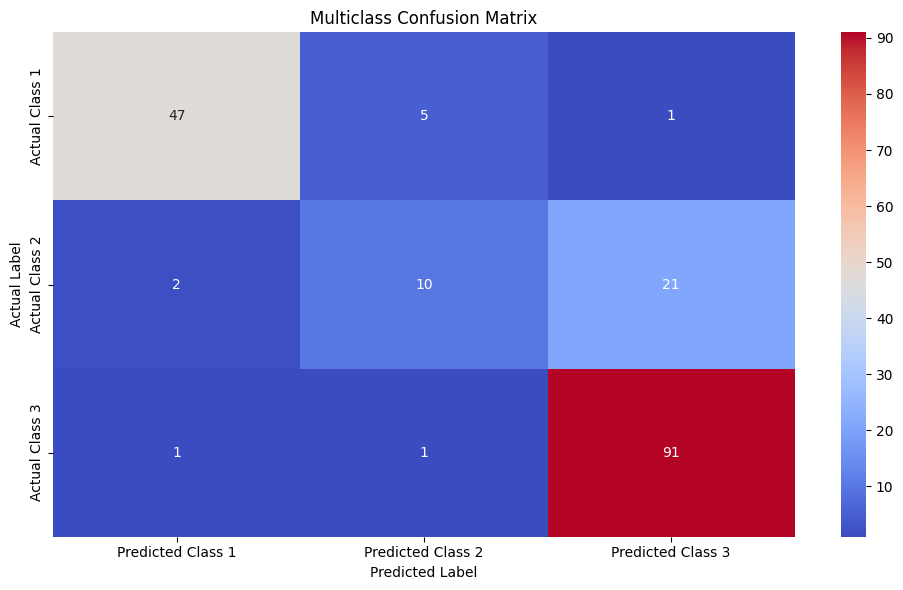

Classification Report:
              precision    recall  f1-score   support

     Class 1       0.94      0.89      0.91        53
     Class 2       0.62      0.30      0.41        33
     Class 3       0.81      0.98      0.88        93

    accuracy                           0.83       179
   macro avg       0.79      0.72      0.73       179
weighted avg       0.81      0.83      0.80       179



In [16]:
cm_multi=confusion_matrix(y_test,muticlass_pred)
print(cm_multi)
plt.figure(figsize=(10,6))
sns.heatmap(cm_multi,annot=True,cmap='coolwarm',fmt='d',xticklabels=['Predicted Class 1','Predicted Class 2','Predicted Class 3'],yticklabels=['Actual Class 1','Actual Class 2','Actual Class 3'])
plt.title('Multiclass Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()
#Classification Report
print("Classification Report:")
print(classification_report(y_test,muticlass_pred,target_names=['Class 1','Class 2','Class 3']))